# Edge AI Optimisation — Results Analysis

In [1]:
import json
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

RESULTS_DIR = '../results'

def load_json(filename):
    path = os.path.join(RESULTS_DIR, filename)
    if not os.path.exists(path):
        print(f'  [MISSING] {path}')
        return None
    with open(path) as f:
        return json.load(f)

def load_csv(filename):
    path = os.path.join(RESULTS_DIR, filename)
    if not os.path.exists(path):
        print(f'  [MISSING] {path}')
        return None
    return pd.read_csv(path)

print('Loading results...')
baseline   = load_json('results_baseline.json')
quantized  = load_json('results_quantized.json')
pruning    = load_json('results_pruning_summary.json')
combined   = load_json('results_combined.json')
federated  = load_json('federated_results.json')
df_fed     = load_csv('federated_results.csv')
print('Done.')

Loading results...
Done.


## 1.  Baseline

In [2]:
if baseline:
    print('===== BASELINE CNN =====')
    print(f"  Train accuracy : {baseline['train_accuracy']:.2f}%")
    print(f"  Test  accuracy : {baseline['test_accuracy']:.2f}%")
    print(f"  Model size     : {baseline['model_size_mb']:.4f} MB")
    print(f"  Parameters     : {baseline['parameters']:,}")
    print(f"  Epochs trained : {baseline['epochs']}")
    print(f"  Batch size     : {baseline['batch_size']}")

===== BASELINE CNN =====
  Train accuracy : 98.89%
  Test  accuracy : 98.50%
  Model size     : 0.0376 MB
  Parameters     : 9,098
  Epochs trained : 5
  Batch size     : 64


## 2.  Quantization

In [3]:
if quantized and baseline:
    acc_drop  = baseline['test_accuracy'] - quantized['test_accuracy']
    size_drop = baseline['model_size_mb'] - quantized['model_size_mb']
    size_pct  = 100 * size_drop / baseline['model_size_mb']

    print('===== DYNAMIC INT8 QUANTIZATION =====')
    print(f"  Method         : {quantized['quantization_type']}")
    print(f"  Test accuracy  : {quantized['test_accuracy']:.2f}%  (Δ {acc_drop:+.2f}pp vs baseline)")
    print(f"  Model size     : {quantized['model_size_mb']:.4f} MB  (↓ {size_pct:.1f}%)")
    print(f"  Test loss      : {quantized['test_loss']:.4f}")

===== DYNAMIC INT8 QUANTIZATION =====
  Method         : PyTorch dynamic int8 quantization
  Test accuracy  : 98.48%  (Δ +0.02pp vs baseline)
  Model size     : 0.0159 MB  (↓ 57.7%)
  Test loss      : 0.0466


## 3.  Pruning experiments

In [4]:
if pruning and baseline:
    rows = []
    for r in pruning:
        rows.append({
            'Model':            r['model_name'],
            'Type':             r['pruning_type'],
            'Amount':           f"{int(r['pruning_amount']*100)}%",
            'Sparsity':         f"{r['sparsity_percent']:.1f}%",
            'Acc (before FT)':  f"{r['test_accuracy_before_finetune']:.2f}%",
            'Acc (after FT)':   f"{r['test_accuracy_after_finetune']:.2f}%",
            'Δ vs Baseline':    f"{r['test_accuracy_after_finetune'] - baseline['test_accuracy']:+.2f}pp",
            'Size (MB)':        f"{r['model_size_mb']:.4f}",
        })
    df_prune = pd.DataFrame(rows)
    print('===== PRUNING SUMMARY =====')
    display(df_prune)

===== PRUNING SUMMARY =====


,Model,Type,Amount,Sparsity,Acc (before FT),Acc (after FT),Δ vs Baseline,Size (MB)
0,"Pruned CNN (unstructured, 30%)",unstructured,30%,30.0%,98.20%,98.85%,+0.35pp,0.0377
1,"Pruned CNN (unstructured, 60%)",unstructured,60%,60.0%,92.45%,98.67%,+0.17pp,0.0377
2,"Pruned CNN (structured, 30%)",structured,30%,4.2%,79.04%,98.59%,+0.09pp,0.0377
3,"Pruned CNN (structured, 60%)",structured,60%,8.4%,32.44%,97.13%,-1.37pp,0.0377


## 4.  Combined (Pruning + Quantization)

In [5]:
if combined and baseline:
    print('===== COMBINED MODEL (PRUNED + QUANTIZED) =====')

    rows = [
        {'Stage': 'Baseline (centralised)',
         'Accuracy': f"{baseline['test_accuracy']:.2f}%",
         'Size (MB)': f"{baseline['model_size_mb']:.4f}",
         'ms/sample': 'N/A'},
        {'Stage': 'Pruned only',
         'Accuracy': f"{combined['pruned_only']['test_accuracy']:.2f}%",
         'Size (MB)': f"{combined['pruned_only']['model_size_mb']:.4f}",
         'ms/sample': f"{combined['pruned_only']['ms_per_sample']:.4f}"},
        {'Stage': 'Pruned + Quantized',
         'Accuracy': f"{combined['combined']['test_accuracy']:.2f}%",
         'Size (MB)': f"{combined['combined']['model_size_mb']:.4f}",
         'ms/sample': f"{combined['combined']['ms_per_sample']:.4f}"},
    ]
    display(pd.DataFrame(rows))

    pr = combined['pruning_amount']
    print(f"\n  Pruning type   : {combined['pruning_type']}  ({int(pr*100)}%)")
    print(f"  Sparsity       : {combined['sparsity_percent']:.1f}%")
    print(f"  Quantization   : {combined['quantization_type']}")

===== COMBINED MODEL (PRUNED + QUANTIZED) =====


,Stage,Accuracy,Size (MB),ms/sample
0,Baseline (centralised),98.50%,0.0376,N/A
1,Pruned only,98.81%,0.0376,0.1885
2,Pruned + Quantized,98.82%,0.0159,0.1877



  Pruning type   : unstructured  (30%)
  Sparsity       : 30.0%
  Quantization   : PyTorch dynamic int8 (Linear layers)



## 5.  Federated Learning

In [6]:
if federated:
    modes = ['float32', 'int8', 'combined']
    rows  = []
    for m in modes:
        if m not in federated:
            continue
        d = federated[m]
        rows.append({
            'Mode':               m,
            'Final accuracy':     f"{d['final_accuracy']:.2f}%",
            'Cost/round (MB)':    f"{d['cost_per_round_mb']:.4f}",
            'Total cost (MB)':    f"{d['total_cost_mb']:.4f}",
            'Avg sparsity':       f"{d.get('avg_sparsity_pct', 0):.1f}%",
            'Rounds→95% (self)':  d.get('rounds_to_95pct_self'),
            'Rounds→95% (bl)':    d.get('rounds_to_95pct_baseline'),
        })

    print('===== FEDERATED LEARNING SUMMARY =====')
    print(f"  Clients      : {federated['num_clients']}")
    print(f"  Rounds       : {federated['rounds']}")
    print(f"  Local epochs : {federated['local_epochs']}")
    print(f"  Parameters   : {federated['parameters']:,}")
    if 'pruning_amount' in federated:
        print(f"  Pruning amt  : {int(federated['pruning_amount']*100)}% (combined mode)")
    print()
    display(pd.DataFrame(rows))

===== FEDERATED LEARNING SUMMARY =====
  Clients      : 5
  Rounds       : 10
  Local epochs : 1
  Parameters   : 9,098
  Pruning amt  : 30% (combined mode)



,Mode,Final accuracy,Cost/round (MB),Total cost (MB),Avg sparsity,Rounds→95% (self),Rounds→95% (bl)
0,float32,98.44%,0.3471,3.4706,0.0%,2,2
1,int8,98.46%,0.0868,0.8677,0.0%,2,2
2,combined,98.41%,0.0697,0.6970,19.7%,1,1


## 6.  Cross-experiment comparison table

In [7]:
rows = []

if baseline:
    rows.append({'Experiment': 'Baseline CNN',
                 'Accuracy (%)': baseline['test_accuracy'],
                 'Size (MB)':    round(baseline['model_size_mb'], 4),
                 'Sparsity (%)': 0.0,
                 'Parameters':   baseline['parameters']})

if quantized:
    rows.append({'Experiment': 'Quantized (int8)',
                 'Accuracy (%)': quantized['test_accuracy'],
                 'Size (MB)':    quantized['model_size_mb'],
                 'Sparsity (%)': 0.0,
                 'Parameters':   quantized['parameters']})

if pruning:
    for r in pruning:
        rows.append({'Experiment': r['model_name'],
                     'Accuracy (%)': r['test_accuracy_after_finetune'],
                     'Size (MB)':    r['model_size_mb'],
                     'Sparsity (%)': r['sparsity_percent'],
                     'Parameters':   r['parameters']})

if combined:
    rows.append({'Experiment': 'Pruned + Quantized',
                 'Accuracy (%)': combined['combined']['test_accuracy'],
                 'Size (MB)':    combined['combined']['model_size_mb'],
                 'Sparsity (%)': combined['sparsity_percent'],
                 'Parameters':   combined['parameters']})

if federated:
    for mode in ['float32', 'int8', 'combined']:
        if mode in federated:
            rows.append({'Experiment': f'Federated ({mode})',
                         'Accuracy (%)': federated[mode]['final_accuracy'],
                         'Size (MB)':    federated[mode]['total_cost_mb'],
                         'Sparsity (%)': federated[mode].get('avg_sparsity_pct', 0),
                         'Parameters':   federated['parameters']})

df_all = pd.DataFrame(rows)
print('===== CROSS-EXPERIMENT COMPARISON =====')
print('(Federated Size (MB) = total communication cost, not model file size)')
display(df_all.style
    .format({'Accuracy (%)': '{:.2f}', 'Size (MB)': '{:.4f}', 'Sparsity (%)': '{:.1f}', 'Parameters': '{:,}'})
    .background_gradient(subset=['Accuracy (%)'], cmap='Greens')
    .background_gradient(subset=['Sparsity (%)'], cmap='Blues')
    .set_caption('Cross-experiment comparison')
)

===== CROSS-EXPERIMENT COMPARISON =====
(Federated Size (MB) = total communication cost, not model file size)


,Experiment,Accuracy (%),Size (MB),Sparsity (%),Parameters
0,Baseline CNN,98.50,0.0376,0.0,"9,098"
1,Quantized (int8),98.48,0.0159,0.0,"9,098"
2,"Pruned CNN (unstructured, 30%)",98.85,0.0377,30.0,"9,098"
3,"Pruned CNN (unstructured, 60%)",98.67,0.0377,60.0,"9,098"
4,"Pruned CNN (structured, 30%)",98.59,0.0377,4.2,"9,098"
5,"Pruned CNN (structured, 60%)",97.13,0.0377,8.4,"9,098"
6,Pruned + Quantized,98.82,0.0159,30.0,"9,098"
7,Federated (float32),98.44,3.4706,0.0,"9,098"
8,Federated (int8),98.46,0.8677,0.0,"9,098"
9,Federated (combined),98.41,0.6970,19.7,"9,098"



## 7.  Plots

### 7a.  Accuracy vs model size (centralised experiments)

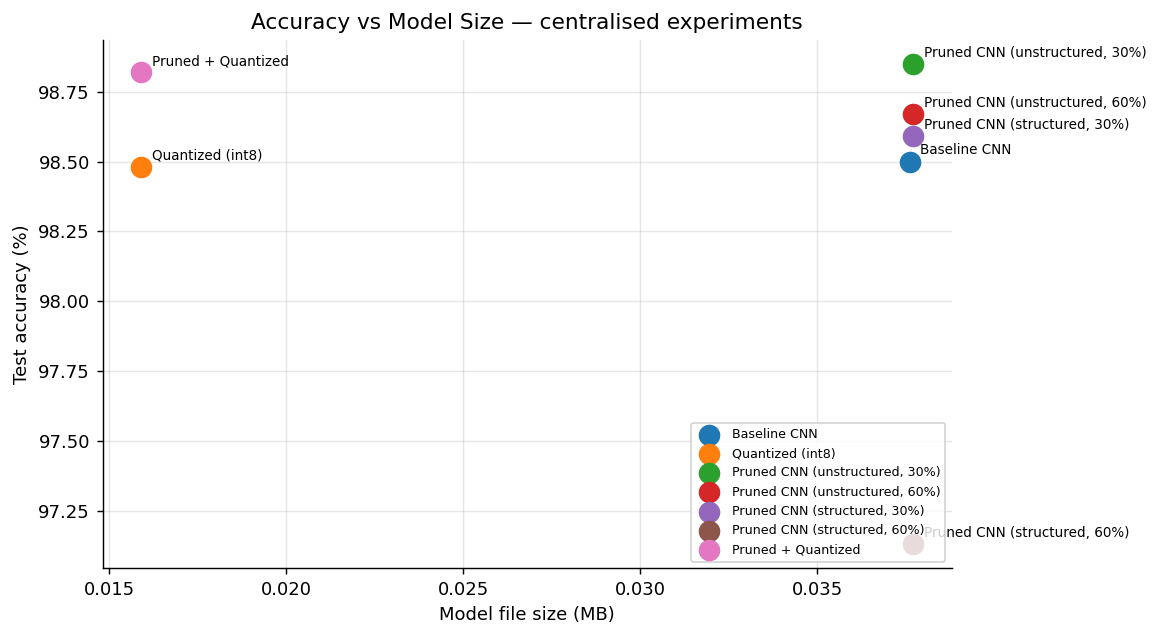

In [8]:
central_rows = [r for r in rows if not r['Experiment'].startswith('Federated')]
df_central   = pd.DataFrame(central_rows)

fig, ax = plt.subplots(figsize=(9, 5))

colors = plt.cm.tab10.colors
for i, (_, row) in enumerate(df_central.iterrows()):
    ax.scatter(row['Size (MB)'], row['Accuracy (%)'],
               s=120, color=colors[i], zorder=3,
               label=row['Experiment'])
    ax.annotate(row['Experiment'],
                xy=(row['Size (MB)'], row['Accuracy (%)']),
                xytext=(6, 4), textcoords='offset points', fontsize=7.5)

ax.set_xlabel('Model file size (MB)')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Accuracy vs Model Size — centralised experiments')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'analysis_accuracy_vs_size.png'), dpi=150)
plt.show()

### 7b.  Federated: accuracy convergence (all three modes)

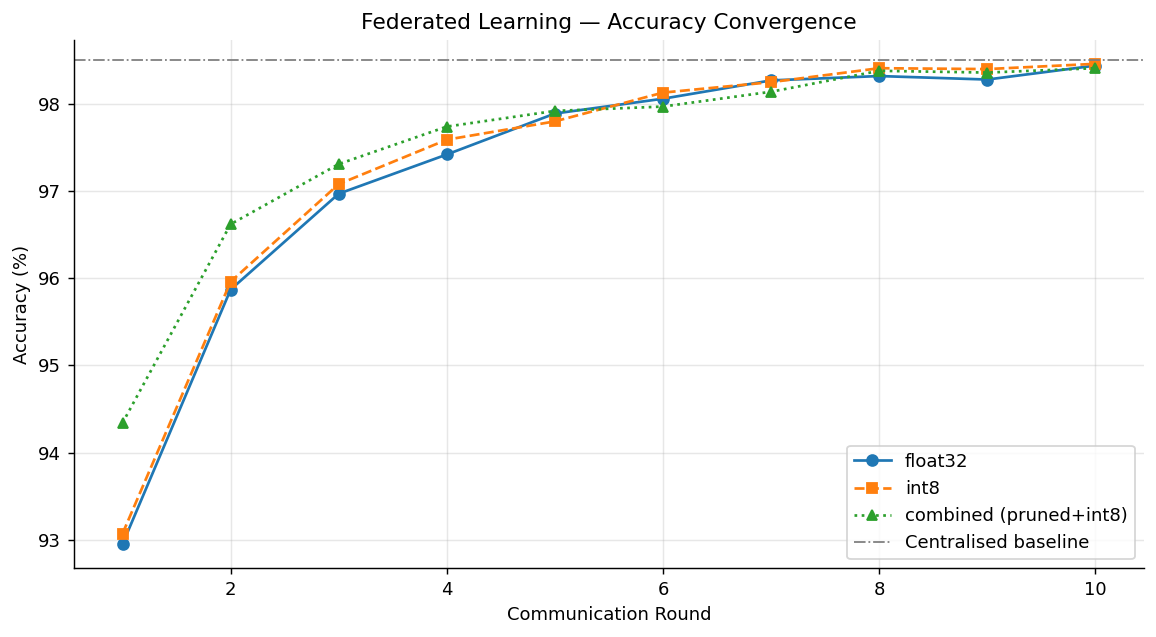

In [9]:
if df_fed is not None:
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(df_fed['round'], df_fed['accuracy_f32'],
            marker='o', label='float32')
    ax.plot(df_fed['round'], df_fed['accuracy_i8'],
            marker='s', linestyle='--', label='int8')

    if 'accuracy_combined' in df_fed.columns:
        ax.plot(df_fed['round'], df_fed['accuracy_combined'],
                marker='^', linestyle=':', label='combined (pruned+int8)')

    if baseline:
        ax.axhline(y=baseline['test_accuracy'], color='grey',
                   linestyle='-.', linewidth=1, label='Centralised baseline')

    ax.set_xlabel('Communication Round')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Federated Learning — Accuracy Convergence')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'analysis_federated_convergence.png'), dpi=150)
    plt.show()

### 7c.  Federated: accuracy vs cumulative communication cost

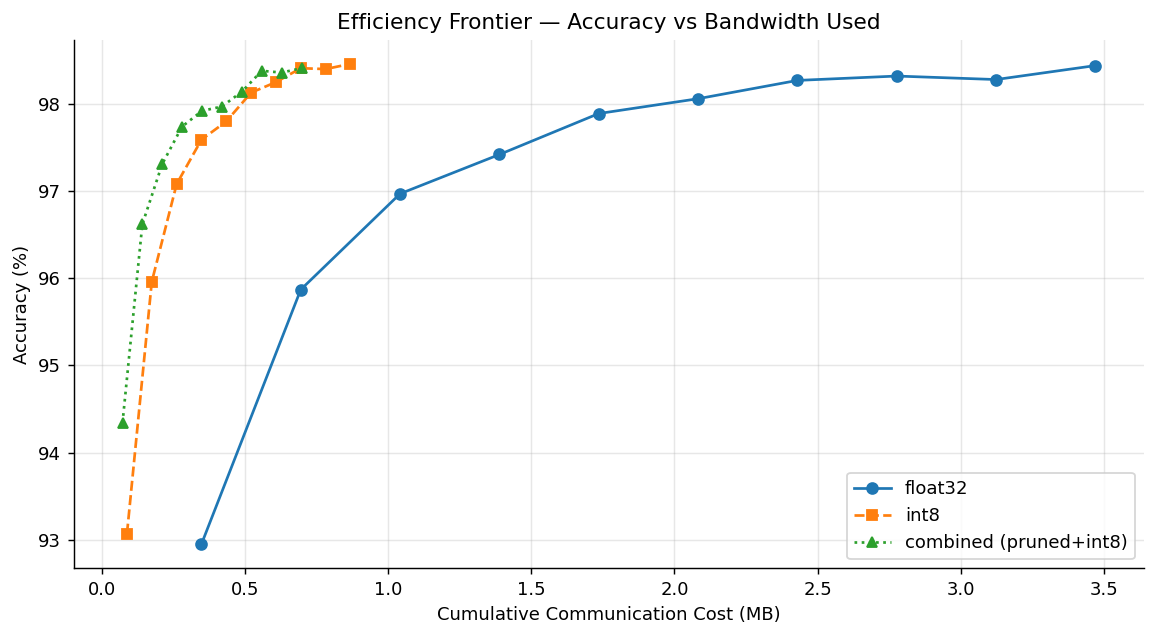

In [10]:
if df_fed is not None:
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(df_fed['cumulative_cost_f32'], df_fed['accuracy_f32'],
            marker='o', label='float32')
    ax.plot(df_fed['cumulative_cost_i8'],  df_fed['accuracy_i8'],
            marker='s', linestyle='--', label='int8')

    if 'cumulative_cost_combined' in df_fed.columns and 'accuracy_combined' in df_fed.columns:
        ax.plot(df_fed['cumulative_cost_combined'], df_fed['accuracy_combined'],
                marker='^', linestyle=':', label='combined (pruned+int8)')

    ax.set_xlabel('Cumulative Communication Cost (MB)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Efficiency Frontier — Accuracy vs Bandwidth Used')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'analysis_federated_efficiency_frontier.png'), dpi=150)
    plt.show()

### 7d.  Bar chart: final accuracy across all experiments

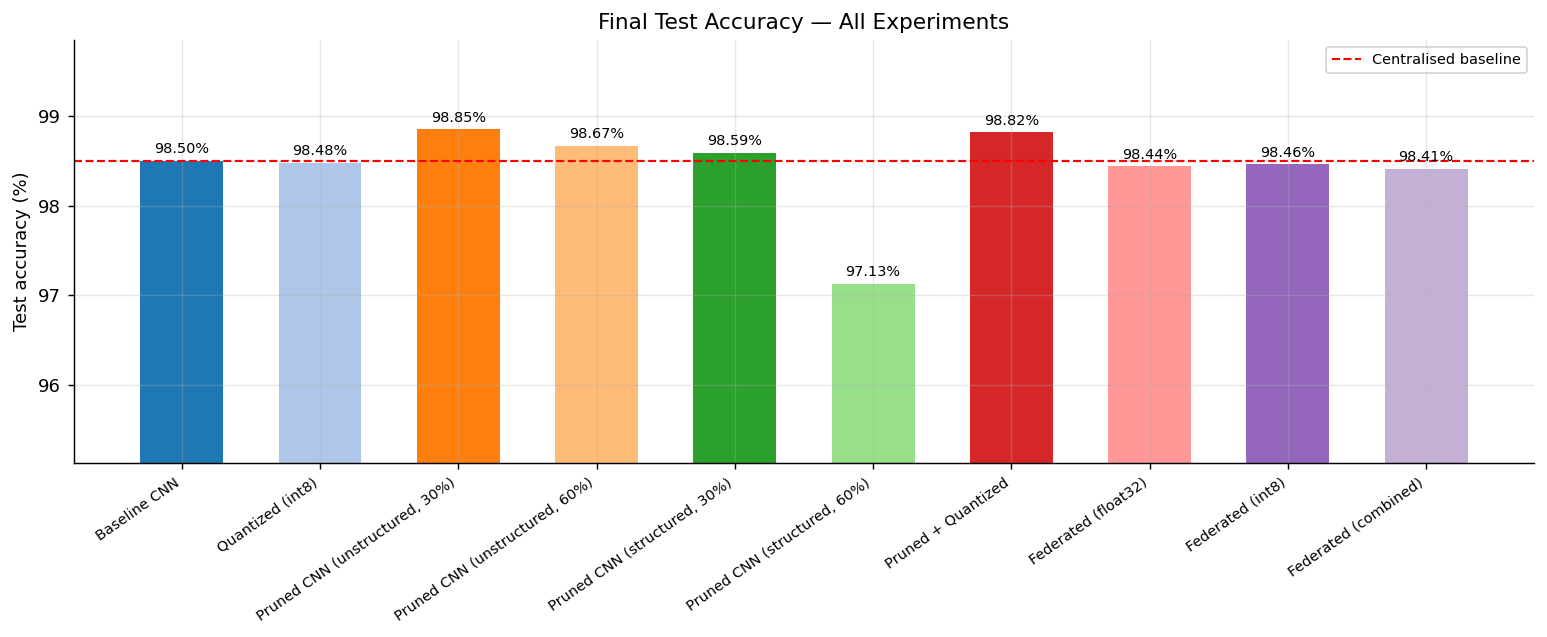

In [11]:
if len(df_all) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))

    labels  = df_all['Experiment'].tolist()
    accvals = df_all['Accuracy (%)'].tolist()
    x       = np.arange(len(labels))

    bars = ax.bar(x, accvals, color=plt.cm.tab20.colors[:len(labels)], width=0.6)

    if baseline:
        ax.axhline(y=baseline['test_accuracy'], color='red',
                   linestyle='--', linewidth=1.2, label='Centralised baseline')

    for bar, val in zip(bars, accvals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Test accuracy (%)')
    ax.set_title('Final Test Accuracy — All Experiments')
    ax.set_ylim([min(accvals) - 2, max(accvals) + 1])
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'analysis_all_accuracy.png'), dpi=150)
    plt.show()

### 7e.  Communication cost breakdown

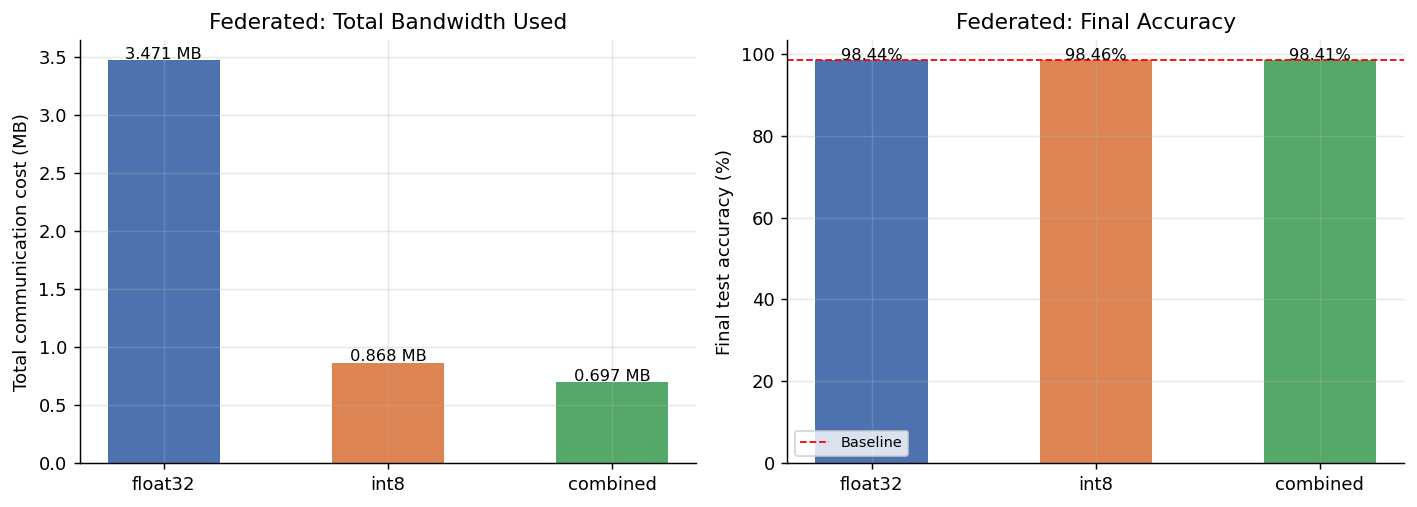

In [12]:
if federated:
    fed_modes   = [m for m in ['float32', 'int8', 'combined'] if m in federated]
    total_costs = [federated[m]['total_cost_mb']   for m in fed_modes]
    final_accs  = [federated[m]['final_accuracy']  for m in fed_modes]

    x   = np.arange(len(fed_modes))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Total cost
    axes[0].bar(x, total_costs, color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(fed_modes)
    axes[0].set_ylabel('Total communication cost (MB)')
    axes[0].set_title('Federated: Total Bandwidth Used')
    for xi, v in zip(x, total_costs):
        axes[0].text(xi, v + 0.01, f'{v:.3f} MB', ha='center', fontsize=9)

    # Final accuracy
    axes[1].bar(x, final_accs, color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(fed_modes)
    axes[1].set_ylabel('Final test accuracy (%)')
    axes[1].set_title('Federated: Final Accuracy')
    if baseline:
        axes[1].axhline(y=baseline['test_accuracy'], color='red',
                        linestyle='--', linewidth=1, label='Baseline')
        axes[1].legend(fontsize=8)
    for xi, v in zip(x, final_accs):
        axes[1].text(xi, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'analysis_federated_cost_accuracy.png'), dpi=150)
    plt.show()


## 8.  Key findings

In [13]:
print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)

if baseline and quantized:
    drop = baseline['test_accuracy'] - quantized['test_accuracy']
    size_red = 100 * (1 - quantized['model_size_mb'] / baseline['model_size_mb'])
    print(f'\nQuantization (int8):')
    print(f'  Accuracy drop  : {drop:.2f}pp')
    print(f'  Size reduction : {size_red:.1f}%')

if pruning and baseline:
    best = max(pruning, key=lambda r: r['test_accuracy_after_finetune'])
    worst = min(pruning, key=lambda r: r['test_accuracy_after_finetune'])
    print(f'\nPruning:')
    print(f'  Best config    : {best["model_name"]}  →  {best["test_accuracy_after_finetune"]:.2f}%')
    print(f'  Worst config   : {worst["model_name"]}  →  {worst["test_accuracy_after_finetune"]:.2f}%')
    print(f'  Max sparsity   : {max(r["sparsity_percent"] for r in pruning):.1f}%')

if combined and baseline:
    drop = baseline['test_accuracy'] - combined['combined']['test_accuracy']
    size_red = 100 * (1 - combined['combined']['model_size_mb'] / baseline['model_size_mb'])
    print(f'\nCombined (pruned + quantized):')
    print(f'  Accuracy drop  : {drop:.2f}pp')
    print(f'  Size reduction : {size_red:.1f}%')
    print(f'  Sparsity       : {combined["sparsity_percent"]:.1f}%')

if federated:
    modes     = [m for m in ['float32', 'int8', 'combined'] if m in federated]
    costs     = {m: federated[m]['total_cost_mb']  for m in modes}
    accs      = {m: federated[m]['final_accuracy']  for m in modes}
    ref_cost  = costs.get('float32', 1)
    print(f'\nFederated Learning:')
    for m in modes:
        saving = 100 * (1 - costs[m] / ref_cost)
        print(f'  [{m:>9}]  accuracy: {accs[m]:.2f}%  |  cost: {costs[m]:.4f} MB  |  saving vs f32: {saving:.1f}%')

KEY FINDINGS

Quantization (int8):
  Accuracy drop  : 0.02pp
  Size reduction : 57.7%

Pruning:
  Best config    : Pruned CNN (unstructured, 30%)  →  98.85%
  Worst config   : Pruned CNN (structured, 60%)  →  97.13%
  Max sparsity   : 60.0%

Combined (pruned + quantized):
  Accuracy drop  : -0.32pp
  Size reduction : 57.7%
  Sparsity       : 30.0%

Federated Learning:
  [  float32]  accuracy: 98.44%  |  cost: 3.4706 MB  |  saving vs f32: 0.0%
  [     int8]  accuracy: 98.46%  |  cost: 0.8677 MB  |  saving vs f32: 75.0%
  [ combined]  accuracy: 98.41%  |  cost: 0.6970 MB  |  saving vs f32: 79.9%
